In [1]:
import sys
import os
import torch
import torch.nn as nn
import pandas as pd

sys.path.append(os.path.abspath('..'))
import config
from src.model.architecture import TinyCNN

# Load the trained model
MODELS_DIR = os.path.join(config.OUTPUTS_DIR, 'models')
checkpoint = torch.load(os.path.join(MODELS_DIR, 'tinycnn_v1.pth'), map_location='cpu')

model = TinyCNN()
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print('Model loaded.')
print(f"  Checkpoint notes: {checkpoint['notes']}")
print(f"  Val accuracy:          {checkpoint['val_acc']:.4f}")
print(f"  Not_meaningful recall: {checkpoint['not_meaningful_recall']:.3f}")
print(f"  Not_meaningful F1:     {checkpoint['not_meaningful_f1']:.3f}")
print()

# Load labels and filter to unknown clips only
labels = pd.read_csv(config.LABELS_PROGRESS_PATH)
unknown = labels[labels['meaningful'] == 'unknown'].copy()

print(f'Total clips in catalog:  {len(labels):,}')
print(f'Unknown clips (to score): {len(unknown):,}')
print()
print('Recorders in unknown pool:')
print(unknown['Recorder'].value_counts())


Model loaded.
  Checkpoint notes: TinyCNN v1 — 2997 not_meaningful clips, diverse split (insect+rain in both splits)
  Val accuracy:          0.9992
  Not_meaningful recall: 0.995
  Not_meaningful F1:     0.982

Total clips in catalog:  631,317
Unknown clips (to score): 509,380

Recorders in unknown pool:
Recorder
Audio_Moth_4    108936
Audio_Moth_5    101612
Audio_Moth_6    100010
Audio_Moth_2     84976
Audio_Moth_1     63413
Audio_Moth_3     50433
Name: count, dtype: int64


In [3]:
import numpy as np
import librosa
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

# Mel parameters — must match exactly what was used in training
SR         = 48000
DURATION   = 3.0
N_MELS     = 128
N_FFT      = 1024
HOP_LENGTH = 512
FMIN       = 50
FMAX       = 16000

def compute_mel(audio_path):
    y, sr = librosa.load(audio_path, sr=SR, duration=DURATION, mono=True)
    expected = int(SR * DURATION)
    if len(y) < expected:
        y = np.pad(y, (0, expected - len(y)))
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX
    )
    return librosa.power_to_db(mel, ref=np.max)[:, :256].astype(np.float32)

class UnknownClipDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            mel = compute_mel(row["audio_path"])
        except Exception:
            # Return zeros for corrupted files — model will score these as meaningful
            # so they won't appear in not_meaningful candidates
            mel = np.zeros((N_MELS, 256), dtype=np.float32)
        return torch.from_numpy(mel).unsqueeze(0), row["clip_name"]

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)

loader = DataLoader(UnknownClipDataset(unknown), batch_size=64, shuffle=False, num_workers=0)

print(f"Scoring {len(unknown):,} unknown clips on {device}...")
print(f"Batches: {len(loader):,} × 64 clips")
print()

results = []
with torch.no_grad():
    for x, clip_names in tqdm(loader, total=len(loader)):
        x = x.to(device)
        probs = torch.sigmoid(model(x).squeeze(1)).cpu().numpy()
        for clip_name, prob in zip(clip_names, probs):
            results.append({"clip_name": clip_name, "not_meaningful_prob": float(1 - prob)})

results_df = pd.DataFrame(results)

out_path = os.path.join(config.OUTPUTS_DIR, "inference_v1.csv")
results_df.to_csv(out_path, index=False)
print(f"Saved {len(results_df):,} predictions to {out_path}")


Scoring 509,380 unknown clips on mps...
Batches: 7,960 × 64 clips



  0%|          | 0/7960 [00:00<?, ?it/s]

/var/folders/b1/ntjf_3gn6zv2k1nf6cml66yw0000gn/T/ipykernel_50133/2688299865.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=SR, duration=DURATION, mono=True)


Saved 509,380 predictions to /Users/qian/KWF/rainforest-audio-detection/outputs/inference_v1.csv


Total clips scored: 509,380

Score distribution (not_meaningful_prob):
       0.0-0.1:  491,664  (96.5%)
       0.1-0.3:    4,211  (0.8%)
       0.3-0.5:    2,718  (0.5%)
       0.5-0.7:    2,476  (0.5%)
       0.7-0.9:    2,439  (0.5%)
      0.9-0.95:    1,275  (0.3%)
     0.95-0.99:    1,817  (0.4%)
      0.99-1.0:    2,780  (0.5%)

High-confidence not_meaningful candidates:
  prob >= 0.90: 5,872 clips
  prob >= 0.95: 4,597 clips
  prob >= 0.99: 2,780 clips

Clips with not_meaningful_prob >= 0.95, by recorder:
Recorder
Audio_Moth_3    3353
Audio_Moth_2     461
Audio_Moth_4     332
Audio_Moth_6     242
Audio_Moth_1     146
Audio_Moth_5      63
Name: count, dtype: int64


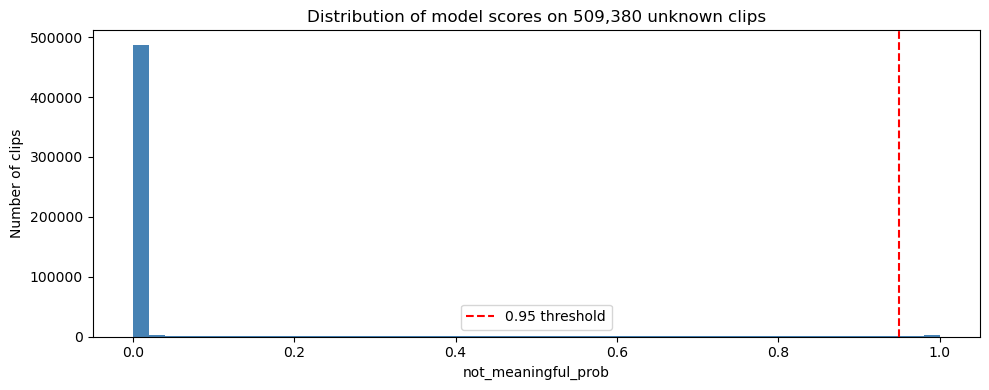

In [4]:
import matplotlib.pyplot as plt

# Load results and join recorder info
results_df = pd.read_csv(os.path.join(config.OUTPUTS_DIR, "inference_v1.csv"))
results_df = results_df.merge(unknown[["clip_name", "Recorder"]], on="clip_name", how="left")

print(f"Total clips scored: {len(results_df):,}")
print()

# Score distribution
print("Score distribution (not_meaningful_prob):")
bins = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.01]
labels_b = ["0.0-0.1", "0.1-0.3", "0.3-0.5", "0.5-0.7", "0.7-0.9", "0.9-0.95", "0.95-0.99", "0.99-1.0"]
results_df["score_band"] = pd.cut(results_df["not_meaningful_prob"], bins=bins, labels=labels_b, right=False)
band_counts = results_df["score_band"].value_counts().sort_index()
for band, count in band_counts.items():
    pct = count / len(results_df) * 100
    print(f"  {band:>12}: {count:>8,}  ({pct:.1f}%)")

print()

# High-confidence thresholds
print("High-confidence not_meaningful candidates:")
for thresh in [0.90, 0.95, 0.99]:
    n = (results_df["not_meaningful_prob"] >= thresh).sum()
    print(f"  prob >= {thresh:.2f}: {n:,} clips")

print()

# By recorder — top not_meaningful candidates
print("Clips with not_meaningful_prob >= 0.95, by recorder:")
high_conf = results_df[results_df["not_meaningful_prob"] >= 0.95]
print(high_conf["Recorder"].value_counts())

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(results_df["not_meaningful_prob"], bins=50, edgecolor="none", color="steelblue")
ax.set_xlabel("not_meaningful_prob")
ax.set_ylabel("Number of clips")
ax.set_title("Distribution of model scores on 509,380 unknown clips")
ax.axvline(0.95, color="red", linestyle="--", label="0.95 threshold")
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
import shutil

AUDIT_DIR = os.path.join(config.OUTPUTS_DIR, "inference_audit")
AUDIO_OUT = os.path.join(AUDIT_DIR, "audio")
AUDIT_CSV = os.path.join(AUDIT_DIR, "inference_audit.csv")
os.makedirs(AUDIO_OUT, exist_ok=True)

rng = np.random.RandomState(42)

# Sample 50 from AM3 (prob >= 0.99) and 30 from other recorders (prob >= 0.95)
am3_candidates = results_df[
    (results_df["Recorder"] == "Audio_Moth_3") &
    (results_df["not_meaningful_prob"] >= 0.99)
]
other_candidates = results_df[
    (results_df["Recorder"] != "Audio_Moth_3") &
    (results_df["not_meaningful_prob"] >= 0.95)
]

am3_sample    = am3_candidates.sample(n=min(50, len(am3_candidates)),   random_state=rng)
other_sample  = other_candidates.sample(n=min(30, len(other_candidates)), random_state=rng)
sample_df = pd.concat([am3_sample, other_sample], ignore_index=True)

print(f"AM3 candidates (prob>=0.99):          {len(am3_candidates):,}")
print(f"Other recorder candidates (prob>=0.95): {len(other_candidates):,}")
print(f"Sampled for audit: {len(sample_df)} clips")
print(f"  AM3:   {len(am3_sample)}")
print(f"  Other: {len(other_sample)}")
print()

# Join audio paths from the unknown pool
sample_df = sample_df.merge(unknown[["clip_name", "audio_path"]], on="clip_name", how="left")

# Copy audio files and build review rows
review_rows = []
missing = 0
for _, row in sample_df.iterrows():
    src = row["audio_path"]
    out_name = f"{row['Recorder']}_{row['clip_name']}"
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(AUDIO_OUT, out_name))
    else:
        missing += 1
        continue
    review_rows.append({
        "clip_name":          row["clip_name"],
        "recorder":           row["Recorder"],
        "not_meaningful_prob": round(row["not_meaningful_prob"], 4),
        "audio_file":         "audio/" + out_name,
        "category":           "",   # background / meaningful / unsure
        "notes":              "",
    })

review_df = pd.DataFrame(review_rows)
review_df = review_df.sort_values(["recorder", "not_meaningful_prob"], ascending=[True, False])
review_df.to_csv(AUDIT_CSV, index=False)

print(f"Audio copied to: {AUDIO_OUT}")
print(f"Review CSV:      {AUDIT_CSV}")
if missing:
    print(f"[WARN] {missing} audio files not found")


AM3 candidates (prob>=0.99):          2,256
Other recorder candidates (prob>=0.95): 1,244
Sampled for audit: 80 clips
  AM3:   50
  Other: 30

Audio copied to: /Users/qian/KWF/rainforest-audio-detection/outputs/inference_audit/audio
Review CSV:      /Users/qian/KWF/rainforest-audio-detection/outputs/inference_audit/inference_audit.csv


In [ ]:
from IPython.display import display, Audio, clear_output
import ipywidgets as widgets

adf = pd.read_csv(AUDIT_CSV)
adf["category"] = adf["category"].fillna("").astype(str)
adf["notes"]    = adf["notes"].fillna("").astype(str)

print(f"Total clips to review: {len(adf)}")
print(f"Already tagged: {(adf['category'] != '').sum()}")
print(f"Remaining:      {(adf['category'] == '').sum()}")

current_idx = [0]
CATEGORIES  = ["background", "meaningful", "unsure"]

category_dropdown = widgets.Dropdown(options=[""] + CATEGORIES, description="Category:", value="")
notes_text   = widgets.Text(description="Notes:", placeholder="optional")
prev_btn     = widgets.Button(description="◀ Prev")
next_btn     = widgets.Button(description="Next ▶", button_style="primary")
save_btn     = widgets.Button(description="💾 Save CSV", button_style="success")
jump_input   = widgets.IntText(value=0, description="Jump to:")
jump_btn     = widgets.Button(description="Go")
status_label = widgets.Label(value="")
output       = widgets.Output()

def show_clip(idx):
    with output:
        clear_output(wait=True)
        if idx < 0 or idx >= len(adf):
            print("Out of range.")
            return
        row = adf.iloc[idx]
        n_tagged = (adf["category"] != "").sum()
        print(f"Clip {idx+1} / {len(adf)}  |  Tagged: {n_tagged}/{len(adf)}")
        print(f"File:     {row['clip_name']}")
        print(f"Recorder: {row['recorder']}  |  not_meaningful_prob: {row['not_meaningful_prob']:.4f}")
        print(f"Current tag: '{row['category']}'  |  Notes: '{row['notes']}'")
        audio_path = os.path.join(AUDIT_DIR, row["audio_file"])
        if os.path.exists(audio_path):
            display(Audio(filename=audio_path))
        else:
            print(f"[Audio not found: {audio_path}]")
    category_dropdown.value = row["category"] if row["category"] in [""] + CATEGORIES else ""
    notes_text.value = row["notes"]

def save_current(auto=False):
    adf.at[current_idx[0], "category"] = category_dropdown.value
    adf.at[current_idx[0], "notes"]    = notes_text.value
    adf.to_csv(AUDIT_CSV, index=False)  # auto-save on every navigation
    n_tagged = (adf["category"] != "").sum()
    status_label.value = f"{'Auto-saved' if auto else '✓ Saved'}. {n_tagged}/{len(adf)} tagged."

def on_next(b):
    save_current(auto=True)
    if current_idx[0] < len(adf) - 1:
        current_idx[0] += 1
        show_clip(current_idx[0])
    else:
        status_label.value = "Reached the end. All progress saved."

def on_prev(b):
    save_current(auto=True)
    if current_idx[0] > 0:
        current_idx[0] -= 1
        show_clip(current_idx[0])

def on_save(b):
    save_current(auto=False)

def on_jump(b):
    save_current(auto=True)
    if 0 <= jump_input.value < len(adf):
        current_idx[0] = jump_input.value
        show_clip(current_idx[0])

next_btn.on_click(on_next)
prev_btn.on_click(on_prev)
save_btn.on_click(on_save)
jump_btn.on_click(on_jump)

display(widgets.VBox([
    output,
    category_dropdown, notes_text,
    widgets.HBox([prev_btn, next_btn, save_btn]),
    widgets.HBox([jump_input, jump_btn]),
    status_label,
]))
show_clip(0)


Total clips to review: 80
Already tagged: 1
Remaining:      79


In [9]:
# Reload to get saved tags
adf = pd.read_csv(AUDIT_CSV)
adf["category"] = adf["category"].fillna("").str.strip().str.lower()

print(f"Total reviewed: {len(adf)}")
print(f"Tagged:         {(adf['category'] != '').sum()}")
print()

print("Overall category distribution:")
print(adf["category"].value_counts())
print()

print("Category by recorder:")
print(pd.crosstab(adf["recorder"], adf["category"]))
print()

# Precision estimate per group
for recorder_group, label in [("Audio_Moth_3", "AM3"), ("other", "Other recorders")]:
    if recorder_group == "Audio_Moth_3":
        subset = adf[adf["recorder"] == "Audio_Moth_3"]
    else:
        subset = adf[adf["recorder"] != "Audio_Moth_3"]
    total = len(subset)
    bg = (subset["category"] == "background").sum()
    if total > 0:
        print(f"{label}: {bg}/{total} background  ({bg/total*100:.0f}% precision)")


Total reviewed: 80
Tagged:         80

Overall category distribution:
category
background    72
meaningful     8
Name: count, dtype: int64

Category by recorder:
category      background  meaningful
recorder                            
Audio_Moth_1           3           2
Audio_Moth_2           7           2
Audio_Moth_3          46           4
Audio_Moth_4          11           0
Audio_Moth_5           1           0
Audio_Moth_6           4           0

AM3: 46/50 background  (92% precision)
Other recorders: 26/30 background  (87% precision)


In [11]:
# Label high-confidence not_meaningful clips in labels_progress.csv
# AM3 at prob >= 0.99, all other recorders at prob >= 0.95

labels = pd.read_csv(config.LABELS_PROGRESS_PATH)

# Load results fresh and join Recorder + current label from labels
results_full = pd.read_csv(os.path.join(config.OUTPUTS_DIR, "inference_v1.csv"))
results_full = results_full.merge(
    labels[["clip_name", "Recorder", "meaningful"]],
    on="clip_name", how="left"
)

# Build candidate mask per recorder group
am3_mask   = (results_full["Recorder"] == "Audio_Moth_3") & \
             (results_full["not_meaningful_prob"] >= 0.99) & \
             (results_full["meaningful"] == "unknown")

other_mask = (results_full["Recorder"] != "Audio_Moth_3") & \
             (results_full["not_meaningful_prob"] >= 0.95) & \
             (results_full["meaningful"] == "unknown")

candidates = results_full[am3_mask | other_mask]["clip_name"].tolist()
print(f"Candidates to label: {len(candidates):,}")
print(f"  AM3 (prob>=0.99):             {am3_mask.sum():,}")
print(f"  Other recorders (prob>=0.95): {other_mask.sum():,}")
print()

# Apply labels — never overwrite an existing confident label
update_mask = labels["clip_name"].isin(candidates) & (labels["meaningful"] == "unknown")
labels.loc[update_mask, "meaningful"]        = "not_meaningful"
labels.loc[update_mask, "meaningful_source"] = "model_inference_v1"

print("Updated label state:")
print(labels["meaningful"].value_counts())
print()
print(labels["meaningful_source"].value_counts())

labels.to_csv(config.LABELS_PROGRESS_PATH, index=False)
print(f"\nSaved to: {config.LABELS_PROGRESS_PATH}")


Candidates to label: 3,500
  AM3 (prob>=0.99):             2,256
  Other recorders (prob>=0.95): 1,244

Updated label state:
meaningful
unknown           505880
meaningful        118940
not_meaningful      6497
Name: count, dtype: int64

meaningful_source
unlabeled              505880
birdnet_species        108069
human_activity          10871
model_inference_v1       3500
background_flatness      2903
background_energy          94
Name: count, dtype: int64

Saved to: /Users/qian/KWF/rainforest-audio-detection/outputs/labels_progress.csv
